# バイナリのパリティと手数料カーブ

バイナリのイベント契約には算術的な恒等式があります。YES と NO は合わせてちょうど 1.00 に決済され
ます。両方のオファーの合計が 1.00 を下回れば、ペアで買って利益を確定できます。このレシピでは、
その乖離をマーケットのパネル全体で測り、次にその大半が手の届かないものである理由を示します。予測
市場の手数料は `p*(1-p)` に比例するので、同じ2セントの乖離でも、5セントでは取引になり、50セント
では損になります。バックテストは同じシグナルを2回、手数料なしと取引所の実際のカーブありで走らせ、
手数料なしの結果は算術と手計算で突き合わせます。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| イベント契約 | 指定した出来事が起きれば 1.00、起きなければ 0.00 を払う契約 |
| YES / NO | 2つのサイド。ちょうど一方だけが払うので、価格がそのまま確率として読める |
| パリティ | YES と NO の合計が 1.00 でなければならないという恒等式 |
| ベーシス | 合計が 1.00 でないときの差。「2セントのベーシス」ならペアの合計が 0.98 |
| アービトラージ | 予測ではなく算術によって確定するポジション |
| 手数料カーブ | `p*(1-p)` に比例する手数料。0.50 で最大、両端でほぼゼロになる |
| 決済 | 確定した結果に基づく支払い。持ち切ったポジションはちょうど 1.00 か 0.00 |
| グロスとネット | 手数料前と手数料後。同じシグナルを2つの設定に通して比べる |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import datetime as dt

import matplotlib.pyplot as plt

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, col

db = h5i_db.Database(cu.fresh_db("05_binary_parity_and_fee_curves"), create=True)

## パネル

`cu.make_prediction_markets` は、バイナリマーケットのパネルについて、バックテストの正規テーブル
4つを返します。気配には意図的にフェイバリット・ロングショット・バイアスが入っていて、NO の板は
YES の板の補数に小さく振動するベーシスを足したものです。そのためセッション中、ペアのコストは
1.00 を両方向にまたぎます。

このレシピが読む入力は `book_deltas` です。1行は、1つのアトミックな板イベントの1つの価格帯です。
同じ `event_index` を持つ行が1つのスナップショットで、最後の行が `is_last=True` を持ちます。

| 列 | 型 | 意味 |
|---|---|---|
| `ts_init` | `timestamp[ns]` | イベントが記録側に届いた時刻。リプレイはこれで並べる |
| `ts_event` | `timestamp[ns]` | 取引所が申告する発生時刻 |
| `instrument_id` | `string` | マーケット |
| `outcome` | `uint16` | 0 = YES、1 = NO |
| `action` | `string` | ここでは `snapshot`。差分やギャップも存在する |
| `side` | `string` | `buy` がビッド側、`sell` がアスク側 |
| `price` | `float64` | 確率。0.001 刻みのグリッド上にある |
| `size` | `float64` | その価格帯に表示されている契約数 |
| `event_index` | `int64` | 行を1つのアトミックなイベントにまとめる |
| `is_last` | `bool` | イベントの終わりを示す |

In [2]:
panel = cu.make_prediction_markets(n_markets=120, steps=32, seed=11)
book = panel["book_deltas"]
print(f"{book.num_rows:,} rows x {book.num_columns} columns")
book.to_pandas().head()

17,280 rows x 11 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,buy,0.098,89.826,1,False,cookbook-sim
1,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,sell,0.114,61.859,1,True,cookbook-sim
2,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,buy,0.874,57.380,2,False,cookbook-sim
3,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,sell,0.890,100.910,2,True,cookbook-sim
4,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0001,0,snapshot,buy,0.098,121.779,3,False,cookbook-sim


## 保存してピン留めする

どのテーブルも、リプレイが並べ替えに使う `ts_init` で時刻インデックスされています。研究を再実行
可能にするのが名前付きスナップショットです。設定に記録されるのはそのピンであって、「あの午後に
テーブルに入っていたもの」ではありません。

In [3]:
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="parity study input")
print({name: db.sql(f"SELECT count(*) AS n FROM {name}").to_pandas()["n"][0] for name in panel})

{'instruments': np.int64(240), 'book_deltas': np.int64(17280), 'trades': np.int64(3840), 'resolutions': np.int64(120)}


## ベーシス

1行が1マーケット1瞬間で、両方のオファーが横に並びます。ペアの買い手は `ask_yes + ask_no` を払い、
決着時にちょうど 1.00 を受け取るので、`1 - pair_cost` が1契約あたりのグロスのエッジです。ミッドも
一緒に持っておきます。手数料はベーシスではなく価格の水準で決まるからです。

In [4]:
# Stop at expiry. The panel keeps quoting after the result is observable, and a
# resolved book sits at ~1.00 / ~0.00: not an opportunity, just an answer.
expiry_ns = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
quotes = db.sql(
    f"""
    SELECT ts_init AS ts, instrument_id, outcome,
           max(CASE WHEN side = 'buy'  THEN price END) AS bid,
           max(CASE WHEN side = 'sell' THEN price END) AS ask
    FROM h5i('book_deltas', 'panel-v1')
    WHERE ts_init <= to_timestamp_nanos({expiry_ns})
    GROUP BY ts_init, instrument_id, outcome
    """
).to_arrow()
db.create_table("quotes", quotes.schema, time_column="ts")
db.append("quotes", quotes.sort_by([("ts", "ascending")]))

yes = db.table("quotes").filter(col("outcome") == 0)
no = db.table("quotes").filter(col("outcome") == 1)
pairs = (
    yes.join(no, on=["ts", "instrument_id"], how="inner")
    .select(
        ts=col("ts", relation="l"),
        instrument_id=col("instrument_id", relation="l"),
        ask_yes=col("ask", relation="l"),
        ask_no=col("ask", relation="r"),
        mid_yes=(col("bid", relation="l") + col("ask", relation="l")) / 2,
    )
    .with_columns(pair_cost=col("ask_yes") + col("ask_no"))
    .with_columns(gross_edge=1.0 - col("pair_cost"))
    .to_pandas()
)
print(f"{len(pairs):,} market-instants")
print(f"pair cost: min {pairs.pair_cost.min():.4f}  median {pairs.pair_cost.median():.4f}  max {pairs.pair_cost.max():.4f}")
print(f"below 1.00 (gross arbitrage): {(pairs.gross_edge > 0).mean():.1%}")

3,840 market-instants
pair cost: min 0.9730  median 1.0120  max 1.0510
below 1.00 (gross arbitrage): 38.4%


## なぜ大半は手が届かないのか

これらの取引所は「想定元本 × レート」では課金しません。手数料は
`rate * quantity * p * (1 - p)` で、確実なところではゼロ、五分五分で最大になります。ペアを買えば
両方のレグで払うので、ペアのハードルは `rate * (p_yes*(1-p_yes) + p_no*(1-p_no))` です。レート7%
なら、両端付近で 0.7 セント、50/50 で 3.5 セントになります。ベーシスは、その価格水準のハードルを
超えてはじめて機会になります。

In [5]:
FEE_RATE = 0.07


def pair_fee(mid_yes: float, rate: float = FEE_RATE) -> float:
    """Kalshi-style quadratic fee for one contract of each leg."""
    mid_no = 1.0 - mid_yes
    return rate * (mid_yes * (1.0 - mid_yes) + mid_no * (1.0 - mid_no))


pairs["fee_hurdle"] = pairs.mid_yes.map(pair_fee)
pairs["net_edge"] = pairs.gross_edge - pairs.fee_hurdle
print(f"clears the hurdle: {(pairs.net_edge > 0).mean():.1%} of market-instants")
for level in (0.05, 0.15, 0.30, 0.50):
    print(f"  hurdle at p={level:.2f}: {pair_fee(level):.4f}")

clears the hurdle: 2.8% of market-instants
  hurdle at p=0.05: 0.0067
  hurdle at p=0.15: 0.0179
  hurdle at p=0.30: 0.0294
  hurdle at p=0.50: 0.0350


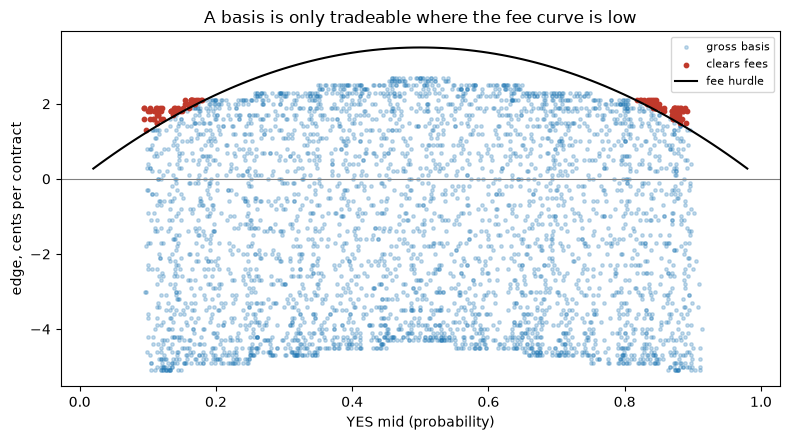

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
survivors = pairs[pairs.net_edge > 0]
ax.scatter(pairs.mid_yes, pairs.gross_edge * 100, s=6, alpha=0.25, label="gross basis")
ax.scatter(survivors.mid_yes, survivors.gross_edge * 100, s=10, color="#c0392b", label="clears fees")
grid = [i / 100 for i in range(2, 99)]
ax.plot(grid, [pair_fee(p) * 100 for p in grid], color="black", lw=1.5, label="fee hurdle")
ax.axhline(0.0, color="grey", lw=0.8)
ax.set_title("A basis is only tradeable where the fee curve is low")
ax.set_xlabel("YES mid (probability)")
ax.set_ylabel("edge, cents per contract")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

## 実際に取引する

1マーケットにつき1ペア、ネットのエッジがハードルを超えた最初の瞬間に出します。選択ルールよりも
大事な点が2つあります。

シグナルには、判断のもとにした気配の1マイクロ秒「あと」の時刻を押します。板の瞬間ちょうどの時刻を
持つ注文は、その瞬間とタイムスタンプを共有するため、1つ前のスナップショットに対してマッチする
ことがあります。判断に使った気配より後に出すやり方は、決定的でもあり誠実でもあります。取引すると
決めた時点で知り得た価格で約定するからです。

`reduce_only` は付けず、両方のレグを成行にしてあるので、この実験が測るのは提示されていたオファー
そのものです。同じ価格の指値にすれば、別の研究になります。

In [7]:
QUANTITY = 20.0
picks = (
    pairs[pairs.net_edge > 0]
    .sort_values(["instrument_id", "ts"])
    .groupby("instrument_id", as_index=False)
    .first()
)
rows = []
for pick in picks.itertuples():
    submit = pick.ts.to_pydatetime() + dt.timedelta(microseconds=1)
    for outcome in (0, 1):
        rows.append(
            {
                "ts": submit,
                "instrument_id": pick.instrument_id,
                "outcome": outcome,
                "side": "buy",
                "quantity": QUANTITY,
                "tag": f"parity-{'yes' if outcome == 0 else 'no'}",
            }
        )
signals = backtest.signal_table(rows).sort_by([("ts", "ascending")])
backtest.create_signal_table(db, "signals")
db.append("signals", signals)
print(f"{len(picks)} markets, {signals.num_rows} legs")
print(f"mean gross edge selected: {picks.gross_edge.mean() * 100:.2f} cents")

27 markets, 54 legs
mean gross edge selected: 1.83 cents


## まずグロス、次にネット

同じシグナルを2つの執行設定で走らせます。データのピンを含め、ほかはすべて固定してあるので、2つの
実行の差は手数料モデルだけから来ます。

In [8]:
def configure(run_id: str, fee_kind: str | None) -> backtest.BacktestConfig:
    execution = (
        backtest.ExecutionConfig(fee_kind=fee_kind, fee_rate=FEE_RATE)
        if fee_kind
        else backtest.ExecutionConfig()
    )
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(signals="signals", snapshot="panel-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=execution,
        metadata={"study": "binary-parity"},
    )


gross = backtest.execute(db, configure("parity-gross", None))
net = backtest.execute(db, configure("parity-kalshi", "kalshi"))


def account(result: backtest.BacktestResult) -> dict[str, float]:
    """Total the run. `realized_pnl` covers closed trades only; these pairs are
    held to resolution, so the result lives in `bt_positions.settlement_pnl`."""
    positions = result.positions.to_pandas()
    summary = result.summary()
    settled = float(positions.settlement_pnl.fillna(0.0).sum())
    fees = float(summary["commissions"])
    # realized_pnl already carries the commissions, so the total is
    # realized + settlement. Here nothing closes before resolution, which makes
    # realized exactly -fees and the two spellings agree; they part company the
    # moment a rule round-trips, so use the one that always holds.
    net = float(summary["realized_pnl"]) + settled
    return {"fills": summary["fills"], "settled": settled, "fees": fees, "net": net}


for label, result in (("gross", gross), ("kalshi fees", net)):
    row = account(result)
    print(
        f"{label:12} fills={row['fills']:>4}  settlement={row['settled']:>8,.2f}  "
        f"fees={row['fees']:>7,.2f}  net={row['net']:>8,.2f}"
    )

gross        fills=  54  settlement=   10.06  fees=   0.00  net=   10.06
kalshi fees  fills=  54  settlement=   10.06  fees=   9.41  net=    0.65


## 算術と突き合わせる

コスト `c` で買ったペアは 1.00 に決済されるので、グロスの結果は、実際に約定したペアについて
`quantity * (1 - c)` を合計した値でなければなりません。意図した価格ではなく `bt_fills` から読むと、
選択、発注のタイミング、マッチング、決済という経路全体を検証できます。

In [9]:
fills = gross.fills.to_pandas()
realized_cost = fills.groupby("instrument_id").price.sum()
expected = float((QUANTITY * (1.0 - realized_cost)).sum())
positions = gross.positions.to_pandas()
booked = float(positions.settlement_pnl.sum())
print(f"pairs filled: {len(realized_cost)} of {len(picks)}")
print(f"expected from arithmetic: {expected:,.2f}")
print(f"booked as settlement:     {booked:,.2f}")
assert abs(expected - booked) < 1e-6, (expected, booked)
after_fees = account(net)
print(f"the same pairs after the real fee curve: {after_fees['net']:,.2f}")
print(f"fees consumed {after_fees['fees'] / expected:.0%} of the gross edge")

pairs filled: 27 of 27
expected from arithmetic: 10.06
booked as settlement:     10.06
the same pairs after the real fee curve: 0.65
fees consumed 94% of the gross edge


## 何が残るか

選択の段階ですでにネットのエッジが正であることを求めているので、ネットの実行も正のまま残ります。
その条件を外すとどうなるかを見るのが、学びのある反実仮想です。グロスのベーシスが正の
マーケット・瞬間をすべて取引すると、手数料カーブがそっくり持っていきます。

In [10]:
naive = pairs[pairs.gross_edge > 0]
print(f"gross-positive opportunities: {len(naive):,}")
print(f"  mean gross edge: {naive.gross_edge.mean() * 100:+.2f} cents")
print(f"  mean net edge:   {naive.net_edge.mean() * 100:+.2f} cents")
print(f"  fraction still positive after fees: {(naive.net_edge > 0).mean():.1%}")
by_level = naive.assign(
    level=lambda f: f.mid_yes.round(1).clip(0.1, 0.9)
).groupby("level").net_edge.mean() * 100
print("\nmean net edge by price level, cents:")
print(by_level.round(2).to_string())

gross-positive opportunities: 1,474
  mean gross edge: +1.52 cents
  mean net edge:   -1.26 cents
  fraction still positive after fees: 7.3%

mean net edge by price level, cents:
level
0.1   -0.25
0.2   -0.84
0.3   -1.43
0.4   -1.72
0.5   -1.74
0.6   -1.67
0.7   -1.45
0.8   -0.79
0.9   -0.31


## まとめ

- YES + NO = 1.00 は恒等式なので、1.00 未満で買ったペアに出来事についての見通しは要らない。
  必要なのは手数料についての見通しである。
- 取引所の手数料は「想定元本 × レート」ではなく `rate * q * p * (1-p)` である。両端ではほぼゼロ、
  五分五分で最悪になる。そしてこれらのマーケットが最も取引されるのは、まさにその近辺である。
- シグナルには、判断に使った気配より厳密にあとの時刻を押す。板イベントとタイムスタンプを共有する
  注文は、1つ前のスナップショットにマッチしうる。
- 会計は決済が担った。`bt_positions.settlement_pnl` は、エンジンが実際に生んだ約定から計算した
  `quantity * (1 - pair_cost)` の算術と、セント単位で一致した。ここで `realized_pnl` だけを読むと
  ゼロになる。決着前に手仕舞ったものがないからである。
- ハードルで選べば、薄いながら正のネットが残る。グロスのベーシスだけで選ぶと、どの価格水準でも
  損をし、五分五分で最も損をする。
- ここで働いた h5i-db の機能。パネルを固定する名前付きスナップショット、両方の結果を1行に載せた
  ビルダの結合、そして `fee_kind` だけが違う、1つのピンの上での2回の実行である。

In [11]:
db.close()